# Beamline Simulation Tutorial: Scripting with `shadow4`
## Part 3 — A Refocusing Mirror with Measured Figure Errors

*Bay Area Light Source Joint User Meeting, 2026*

**Contact:**
- Wei "Francis" He — francisho@lbl.gov
- Dr. Antoine Islegen-Wojdyla — awojdyla@lbl.gov

**Acknowledgements:**

Beamline parameters are taken from the ALS-U COSMIC-U (7.0.1) optical design. The height map is a metrology measurement of COSMIC-U's M103 mirror.

---

## This Notebook: Metrology Complicating Actual Tracing (MCAT)

Part 2's monochromator, followed by an elliptical mirror that refocuses the beam horizontally onto the same screen. The mirror is not ideal: it carries the height errors measured on a real optic. We take the export apart as before, look at how the measured map is put on the mirror, and then move the errors to the optic where they cost resolution.

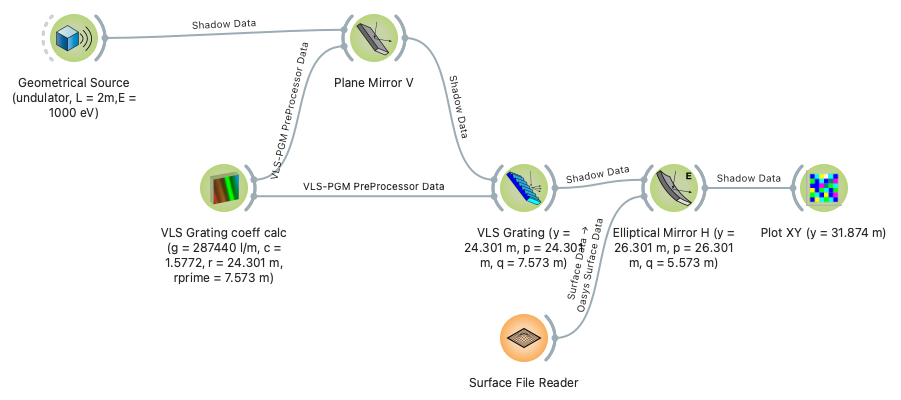

Source → plane mirror (V) → VLS grating, 287 440 lines/m (V) → elliptical cylinder at 26.301 m with measured figure errors (H) → screen at 31.874 m.

### Contents

- **0. Setup** — packages and imports.
- **1. The script from Oasys** — the export, and what is new with a third optic.
- **2. Retrace and plot** — which column is which after three optics, and how to check it.
- **3. Component breakdown** — every block rebuilt and checked ray for ray against the paste, including the measured height map and how it is put on the mirror.
- **4. An error on the pre-mirror** — building a surface error out of arrays, and what one costs on the optic where it costs the most.

### Resources

- shadow4 source code and examples: [github.com/oasys-kit/shadow4](https://github.com/oasys-kit/shadow4)
- Oasys: [github.com/oasys-kit](https://github.com/oasys-kit)

## 0. Setup

```bash
pip install shadow4 h5py
```

Same packages as Part 1, plus `h5py` to open the height-map file. `scipy` arrives with shadow4 and is used in Sections 4 and the appendix. Tested with Python 3.13 and shadow4 0.1.92.

The three data files — two measured mirrors and a set of actuator influence functions — ship with this notebook in `data/`; run the notebook from the folder it lives in.

In [1]:
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt

for pkg in ["shadow4", "syned", "srxraylib", "h5py", "scipy", "numpy", "matplotlib"]:
    print(f"{pkg:11s} {version(pkg)}")

shadow4     0.1.88
syned       1.0.57
srxraylib   1.0.68
h5py        3.16.0
scipy       1.18.0
numpy       2.5.2
matplotlib  3.11.1


## 1. The Script from Oasys

Output of the *Python Script* widget attached to the *Plot XY* in the canvas above.  

> __Notes:__ 
> - On the _Plot XY_ widget, select 'retraced' for 'Position of the image'.
> **One line changed**: `surface_data_file`. The export records the absolute path of the height map on the computer that wrote it; here it points at the copy in `data/`, next to this notebook.

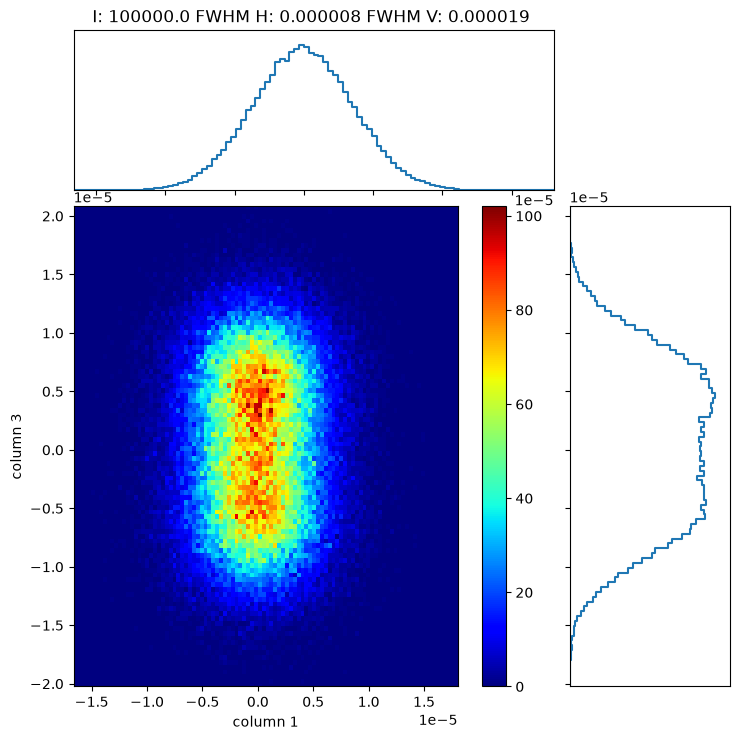

(<Figure size 800x800 with 4 Axes>,
 <Axes: xlabel='column 1', ylabel='column 3'>,
 <Axes: title={'center': 'I: 100000.0 FWHM H: 0.000008 FWHM V: 0.000019 '}>,
 <Axes: >)

In [2]:
import numpy as np

def run_beamline():
    footprint = None
    import numpy as np
    from dabax.dabax_xraylib import DabaxXraylib
    from shadow4.beamline.s4_beamline import S4Beamline
    
    beamline = S4Beamline()
    
    #
    #
    #
    from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
    light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
    light_source.set_spatial_type_gaussian(sigma_h=1.65e-05,sigma_v=1.84e-05)
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=1.86e-05,sigdiz=1.83e-05)
    light_source.set_energy_distribution_singleline(1000, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    beam = light_source.get_beam()
    
    beamline.set_light_source(light_source)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155)
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='Plane Mirror V', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.09, y_top=0.09)
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating
    optical_element = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
        boundary_shape=None, f_ruling=1, order=-1,
        ruling=287440.0, ruling_coeff_linear=142771.836, 
        ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
        ruling_coeff_quartic=0.0,
        )
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)
    movements = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
    beamline_element = S4PlaneGratingElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.1258, y_top=0.126)
            
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror
    optical_element = S4EllipsoidMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)', boundary_shape=boundary_shape,
        surface_calculation=0, # 0=Internal calculation, 1=External 
        min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
        p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156, # for surface_calculation=0
        is_cylinder=1, cylinder_direction=0, convexity=1,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    ideal_mirror = optical_element
    boundary_shape = None
            
    from shadow4.beamline.optical_elements.mirrors.s4_numerical_mesh_mirror import S4NumericalMeshMirror
    optical_element = S4NumericalMeshMirror(name='Numerical Mesh Mirror', boundary_shape=boundary_shape,
        xx=None, yy=None, zz=None, surface_data_file='data/shadow4_COSMIC-U_M3_AXO_DLTP_Resid_4thOrderRemoved_IntResidHeight.h5',
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='', # for f_refl=0,2,3,4
        refraction_index=1, # for f_refl=1
        coating_material='', coating_density=1, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    numerical_mesh_mirror = optical_element
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.1258, y_top=0.126)
    
    from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirror
    optical_element = S4AdditionalNumericalMeshMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)', ideal_mirror=ideal_mirror, numerical_mesh_mirror=numerical_mesh_mirror)
        
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=-5.573, q=5.573, angle_radial=1.548979711, angle_azimuthal=4.71238898, angle_radial_out=1.548979711)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirrorElement
    beamline_element = S4AdditionalNumericalMeshMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    return beam, footprint

#
# main 
#
from srxraylib.plot.gol import plot, plot_image, plot_image_with_histograms, plot_show

# WARNING: NO incremental result allowed!!"
beam, footprint = run_beamline()
beam.retrace(0.000000)

ticket = beam.histo2(1, 3, nbins_h=100, nbins_v=100, xrange=[np.float64(-1.680199711291622e-05), np.float64(1.8205081784753407e-05)], yrange=[np.float64(-2.044560335860053e-05), np.float64(2.1023667982123877e-05)], nolost=1, ref=23)

title = "I: %.1f " % ticket['intensity']
if ticket['fwhm_h'] is not None: title += "FWHM H: %f " % ticket['fwhm_h']
if ticket['fwhm_v'] is not None: title += "FWHM V: %f " % ticket['fwhm_v']

plot_image_with_histograms(ticket['histogram'], ticket['bin_h_center'], ticket['bin_v_center'],
    title=title, xtitle="column 1", ytitle="column 3",
    cmap='jet', add_colorbar=True, figsize=(8, 8), histo_path_flag=1, show=1)

### What is new compared with Parts 1 and 2

Model 3 is Models 1 and 2 in one canvas: Part 2's monochromator, then Part 1's elliptical mirror. The source, the plane mirror and the grating are Part 2's blocks, line for line. The third element block is Part 1's mirror, with two differences — where it sits, and what its surface is.

**The surface is measured, not ideal.** That is what this notebook is about, and it is why the block builds three objects instead of one:

```python
optical_element = S4EllipsoidMirror(...)                  # the ideal ellipse, as in Part 1
ideal_mirror = optical_element

optical_element = S4NumericalMeshMirror(..., surface_data_file=...)   # the measured height map
numerical_mesh_mirror = optical_element

optical_element = S4AdditionalNumericalMeshMirror(ideal_mirror=ideal_mirror,
                                                  numerical_mesh_mirror=numerical_mesh_mirror)
```

The map is **added to** the ideal ellipse rather than used in its place: the file holds deviations of a few nanometres, not the shape of a mirror. The combined optic takes its aperture from the ideal mirror, −125.8 to +126.0 mm along its length; the `Rectangle` built just before `S4AdditionalNumericalMeshMirror` is passed to nothing, the same pattern as the grating's aperture in Part 2.

**Where it sits.** Azimuth 3π/2, so it deflects and focuses horizontally while the monochromator works vertically — Part 1's mirror, with the beam bent the other way. And `p` = −5.573 m, which is negative. The grating's `q` = 7.573 m carries the rays all the way to the screen plane at 31.874 m; the mirror's `p` then steps back 5.573 m from there, putting the mirror at 26.301 m, and its `q` = 5.573 m brings the beam forward to the screen again.

## 2. Retrace and Plot

`# main` is Part 1's: trace, `retrace(0)`, `histo2` on columns 1 and 3. What changes with three optics is which lab direction each column is.

### 2.1 Which column is which

Three optics, three azimuths, and the column frame turns with each of them. The summary, if the bookkeeping is getting confusing:

| After | Azimuth | Deflects | Column 1 | Column 3 |
|---|---|---|---|---|
| plane mirror | 0 | vertically | lab horizontal | lab vertical |
| grating | π | vertically | lab horizontal | lab vertical — dispersed and focused by the grating |
| elliptical mirror | 3π/2 | horizontally | **lab vertical** | **lab horizontal** — focused by the mirror |

The rule behind it is Part 1's: after each optic, column 3 lies in that optic's deflection plane and column 1 across it. So at the screen column 1 is the grating's dispersive direction, and column 3 is the direction the elliptical mirror focuses. Both are in focus here.

**You don't have to take the table's word for it.** One thing you can always do is ask the rays where they came from. A ray keeps its row in `beam.rays` from one end of the beamline to the other: tracing overwrites each row in place, and a ray that misses an aperture is flagged in column 10 rather than dropped, so nothing is ever reordered or removed. Row *i* at the screen is the ray that left the source in row *i* — column 12, the ray index, still matches its row.

Nothing has to be propagated a second time, then: draw the source again on its own — same settings, same seed, so the same rays (Part 1, 3.1) — and colour each ray at the screen by the position it started from. If the redrawn source were a different draw, every panel below would be structureless noise.

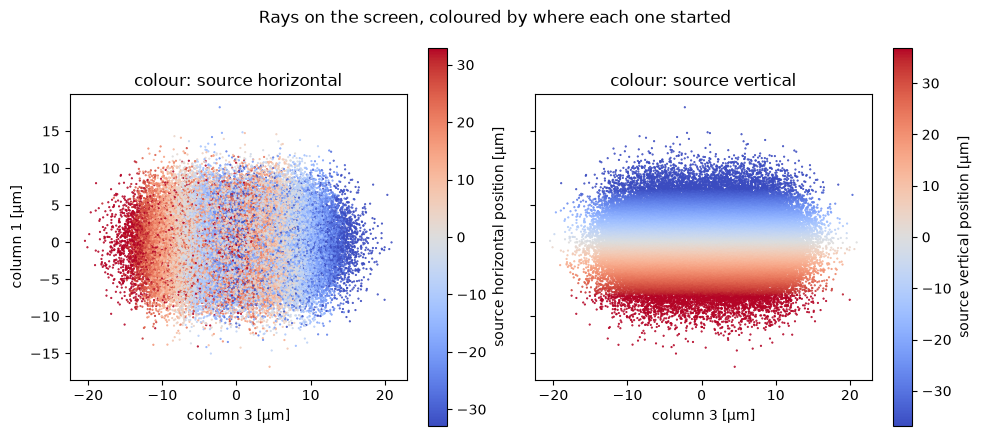

correlation with the source's    horizontal (x)   vertical (z)
   column 1                         -0.004          -1.000
   column 3                         -0.505          -0.002


In [3]:
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical

# The export's source block again, rays only: same settings and same seed, so these are
# the same 100 000 rays, in the same order, before any optic touched them.
src = SourceGeometrical(nrays=100000, seed=12)
src.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
src.set_depth_distribution_off()
src.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
src.set_energy_distribution_singleline(1000, unit='eV')
src.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
start = src.get_beam().rays

# Column 12 is the ray index: at the screen it still equals the row number, so the rays
# have neither been reordered nor removed.
assert np.array_equal(beam.rays[:, 11], np.arange(1, beam.rays.shape[0] + 1))

good = beam.rays[:, 9] > 0
col1_um, col3_um = beam.rays[good, 0] * 1e6, beam.rays[good, 2] * 1e6

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharex=True, sharey=True)
for ax, (src_col, name) in zip(axes, [(0, "horizontal"), (2, "vertical")]):
    start_um = start[good, src_col] * 1e6
    lim_um = 2 * start_um.std()
    sc = ax.scatter(col3_um, col1_um, c=start_um, s=0.3, cmap="coolwarm",
                    vmin=-lim_um, vmax=lim_um, rasterized=True)
    fig.colorbar(sc, ax=ax, label=f"source {name} position [µm]")
    ax.set_title(f"colour: source {name}")
    ax.set_xlabel("column 3 [µm]")
    ax.set_aspect("equal")
axes[0].set_ylabel("column 1 [µm]")
fig.suptitle("Rays on the screen, coloured by where each one started")
plt.tight_layout()
plt.show()

corr = lambda a, b: np.corrcoef(a, b)[0, 1]
r = {(col, s): corr(beam.rays[good, col - 1], start[good, s - 1]) for col in (1, 3) for s in (1, 3)}
print("correlation with the source's    horizontal (x)   vertical (z)")
for col in (1, 3):
    print(f"   column {col}                         {r[(col, 1)]:+.3f}          {r[(col, 3)]:+.3f}")

assert abs(r[(1, 3)]) > 0.99                              # column 1 is the source's vertical, ray for ray
assert abs(r[(1, 1)]) < 0.02 and abs(r[(3, 3)]) < 0.02    # neither column mixes in the other direction
assert abs(r[(3, 1)]) > 10 * abs(r[(3, 3)])               # column 3 follows the source's horizontal

Column 1 is the source's vertical position, ray for ray, inverted — which is what the −1.000 means: the grating images it sharply. Column 3 follows the source's horizontal position only loosely — something between the source and the screen is scattering the rays horizontally. That is the mirror's figure error, and Section 3 puts it there on purpose.

### 2.2 The beam at the screen

Three lines of bookkeeping, used for the rest of the notebook: the rms and centroid of a column over the good rays, and the map from columns to lab axes. Each direction is imaged exactly once — the grating images the source vertically, the mirror horizontally — so both are inverted; and the mirror's azimuth of 3π/2 turns the beam frame through a further 180°. The two cancel, and lab horizontal is +column 3 with lab vertical +column 1.

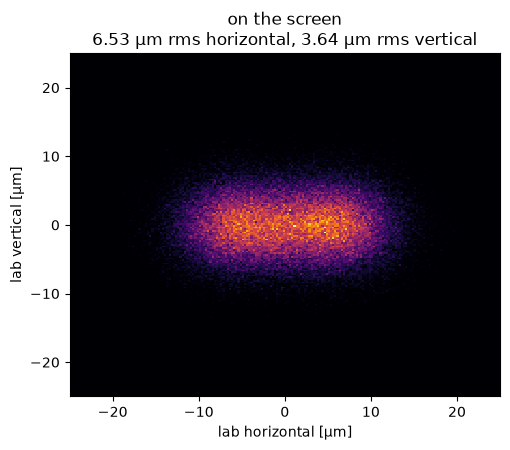

column 1 (lab vertical):   3.64 µm rms   vertical source through the grating: 3.64 µm
column 3 (lab horizontal): 6.53 µm rms   horizontal source through an ideal ellipse: 3.50 µm


In [4]:
def rms(b, col):
    # rms of a Shadow column (numbered from 1) over good rays
    return b.rays[b.rays[:, 9] > 0, col - 1].std()

def centroid(b, col):
    return b.rays[b.rays[:, 9] > 0, col - 1].mean()

def lab_frame(b):
    # (lab horizontal, lab vertical up) positions of the good rays [m], for this beamline
    g = b.rays[:, 9] > 0
    return b.rays[g, 2], b.rays[g, 0]

r_m, r_prime_m = 24.301, 7.573                    # grating: source distance, image distance
alpha_rad, beta_rad = 1.548912027, 1.536274133    # grating angles, from the export
p_m, q_m = 26.301, 5.573                          # elliptical mirror
sigma_h_m, sigma_v_m = 1.65e-5, 1.84e-5           # source rms size

lab_h_m, lab_v_m = lab_frame(beam)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.hist2d(lab_h_m * 1e6, lab_v_m * 1e6, bins=[200, 200],
          range=[[-25, 25], [-25, 25]], cmap="inferno")
ax.set_xlabel("lab horizontal [µm]")
ax.set_ylabel("lab vertical [µm]")
ax.set_title(f"on the screen\n{lab_h_m.std() * 1e6:.2f} µm rms horizontal, "
             f"{lab_v_m.std() * 1e6:.2f} µm rms vertical")
plt.tight_layout()
plt.show()

col1_expected_m = sigma_v_m * r_prime_m * np.cos(alpha_rad) / (r_m * np.cos(beta_rad))   # Part 2
col3_ideal_m = sigma_h_m * q_m / p_m                                                     # Part 1

print(f"column 1 (lab vertical):   {rms(beam, 1) * 1e6:.2f} µm rms   "
      f"vertical source through the grating: {col1_expected_m * 1e6:.2f} µm")
print(f"column 3 (lab horizontal): {rms(beam, 3) * 1e6:.2f} µm rms   "
      f"horizontal source through an ideal ellipse: {col3_ideal_m * 1e6:.2f} µm")

assert np.isclose(rms(beam, 1), col1_expected_m, rtol=0.01)   # the mirror leaves column 1 alone
assert rms(beam, 3) > 1.4 * col3_ideal_m                      # and column 3 is well short of ideal

Column 1 is Part 2's number: a horizontally deflecting mirror does not touch the dispersive direction. Column 3 is nearly twice what an ideal ellipse delivers.

## 3. Component Breakdown

The same script, one block per cell. Each optic gets its own name, so all three stay around to inspect. Section 3.3 checks the rebuilt beam against the pasted one.

In [5]:
beam_paste = beam.duplicate()   # keep the pasted script's result for the comparison in 3.3

### 3.1 Source and monochromator

Part 2's cells, unchanged: the source, the plane mirror, the grating, and the check that the export's angles and distances solve the grating equation and the focus condition at 1000 eV. Part 2, Section 3, explains each argument.

In [6]:
light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
light_source.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
light_source.set_depth_distribution_off()
light_source.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
light_source.set_energy_distribution_singleline(1000, unit='eV')
light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
beam = light_source.get_beam()

In [7]:
from syned.beamline.shape import Rectangle
from syned.beamline.element_coordinates import ElementCoordinates
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating

mirror = S4PlaneMirror(name='Plane Mirror V',
    boundary_shape=Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155),
    f_reflec=0,
    f_refl=0, file_refl='<none>', refraction_index=0.99999+0.001j,
    coating_material='Si', coating_density=2.33, coating_roughness=0,
    dabax=None,
    )
mirror_coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)

grating = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
    boundary_shape=None, f_ruling=1, order=-1,
    ruling=287440.0, ruling_coeff_linear=142771.836,
    ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
    ruling_coeff_quartic=0.0,
    )
grating_coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)

In [8]:
hc_eVm = 1.239841984e-6                      # h·c [eV·m]
g0_per_m, g1_per_m2 = 287440.0, 142771.836   # ruling [l/m], [l/m²]
r_m, r_prime_m, dy_m = 24.301, 7.573, 0.010

alpha_rad, beta_rad = grating_coordinates.angle_radial(), grating_coordinates.angle_radial_out()
wavelength_m = hc_eVm / 1000.0
D_rad = np.pi - alpha_rad - beta_rad
L_MG_m = dy_m / np.sin(D_rad)
d_SM_m = r_m - dy_m / np.tan(D_rad)

assert np.isclose(np.sin(alpha_rad) - np.sin(beta_rad), wavelength_m * g0_per_m, rtol=1e-6)
assert np.isclose(np.cos(alpha_rad)**2 / r_m + np.cos(beta_rad)**2 / r_prime_m, wavelength_m * g1_per_m2, rtol=1e-5)
assert np.isclose(mirror_coordinates.angle_radial(), (alpha_rad + beta_rad) / 2, atol=1e-9)
assert np.isclose(d_SM_m, mirror_coordinates.p(), atol=1e-6)
assert np.isclose(L_MG_m, mirror_coordinates.q() + grating_coordinates.p(), atol=1e-6)
print("The export's monochromator is Part 2's: grating equation, focus condition and layout all hold at 1000 eV.")

The export's monochromator is Part 2's: grating equation, focus condition and layout all hold at 1000 eV.


### 3.2 Refocusing mirror

Three objects, in the export's order:

- **`ideal_mirror`** — Part 1's elliptical cylinder: same `p_focus`, `q_focus` and grazing angle. Its aperture is 20 mm wide and runs from −125.8 to +126.0 mm along the mirror, which is exactly the span of the measurement below.
- **`numerical_mesh_mirror`** — the measured height map, read from the file. Its aperture and reflectivity arguments are placeholders: the combined optic takes both from the ideal mirror.
- **`measured_mirror`** — the sum: the ideal ellipse plus the measured deviations. This is the optic that gets traced.

In [9]:
from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror
from shadow4.beamline.optical_elements.mirrors.s4_numerical_mesh_mirror import S4NumericalMeshMirror
from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirror

surface_file = "data/shadow4_COSMIC-U_M3_AXO_DLTP_Resid_4thOrderRemoved_IntResidHeight.h5"

ideal_mirror = S4EllipsoidMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)',
    boundary_shape=Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.1258, y_top=0.126),
    surface_calculation=0,
    min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
    p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156,
    is_cylinder=1, cylinder_direction=0, convexity=1,
    f_reflec=0,
    f_refl=0, file_refl='<none>', refraction_index=0.99999+0.001j,
    coating_material='Si', coating_density=2.33, coating_roughness=0,
    dabax=None,
    )

numerical_mesh_mirror = S4NumericalMeshMirror(name='Numerical Mesh Mirror', boundary_shape=None,
    xx=None, yy=None, zz=None, surface_data_file=surface_file,
    f_reflec=0,
    f_refl=0, file_refl='', refraction_index=1,
    coating_material='', coating_density=1, coating_roughness=0,
    dabax=None,
    )

measured_mirror = S4AdditionalNumericalMeshMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)',
                                                  ideal_mirror=ideal_mirror,
                                                  numerical_mesh_mirror=numerical_mesh_mirror)

assert measured_mirror.get_boundary_shape() is ideal_mirror.get_boundary_shape()   # the aperture is the ideal mirror's

#### The figure error

The file is the mirror's height map: how far its surface sits from the ideal ellipse at each point, measured with a slope-measuring profilometer and integrated to height. Nothing in the beamline reads it except `S4NumericalMeshMirror`, but it is worth opening — it is the only new physics in this notebook, and a map that turns out to be tilted, offset or shorter than the optic explains a lot of otherwise surprising spots.

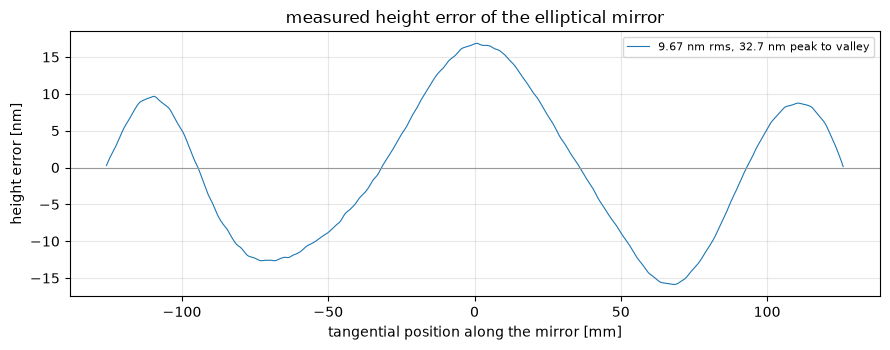

map: 1260 points over 251.8 mm, 2.00e-04 m apart, tiled across ±16 mm
height 9.67 nm rms   slope 0.572 µrad rms
aperture -125.8000 … 126.0000 mm against map -125.8000 … 126.0000 mm  -> 11 nm of aperture outside the map


In [10]:
import h5py

with h5py.File(surface_file, "r") as f:
    map_x_m = f["surface_file/X"][()]     # across the mirror (sagittal)
    map_y_m = f["surface_file/Y"][()]     # along the mirror (tangential)
    map_z_m = f["surface_file/Z"][()]     # height deviation, shape (len(y), len(x))

# A slope profilometer scans one line; the file repeats it across the width.
assert np.allclose(map_z_m, map_z_m[:, [0]])
height_m = map_z_m[:, 0]
slope_rad = np.gradient(height_m, map_y_m)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(map_y_m * 1e3, height_m * 1e9, lw=0.8,
        label=f"{height_m.std() * 1e9:.2f} nm rms, {np.ptp(height_m) * 1e9:.1f} nm peak to valley")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("tangential position along the mirror [mm]")
ax.set_ylabel("height error [nm]")
ax.set_title("measured height error of the elliptical mirror")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"map: {map_y_m.size} points over {np.ptp(map_y_m) * 1e3:.1f} mm, "
      f"{map_y_m[1] - map_y_m[0]:.2e} m apart, tiled across ±{map_x_m.max() * 1e3:.0f} mm")
print(f"height {height_m.std() * 1e9:.2f} nm rms   slope {slope_rad.std() * 1e6:.3f} µrad rms")

# The aperture has to sit inside the map: outside it, the surface is whatever the
# interpolating spline extrapolates, which is nobody's mirror.
x_left, x_right, y_bottom, y_top = ideal_mirror.get_boundary_shape().get_boundaries()
overhang_m = max(map_y_m.min() - y_bottom, y_top - map_y_m.max(),
                 map_x_m.min() - x_left, x_right - map_x_m.max())
print(f"aperture {y_bottom * 1e3:.4f} … {y_top * 1e3:.4f} mm against map "
      f"{map_y_m.min() * 1e3:.4f} … {map_y_m.max() * 1e3:.4f} mm  "
      f"-> {overhang_m * 1e9:.0f} nm of aperture outside the map")
assert overhang_m < 1e-6

**Placement.** Azimuth 3π/2, 1.25° grazing, `p` = −5.573 m back from the screen plane (Section 1). The ellipse's `p_focus`, 26.301 m, has to be the distance the beam actually travels from the source to the mirror — through the monochromator, which lengthens the path slightly.

In [11]:
ellipse_coordinates = ElementCoordinates(p=-5.573, q=5.573, angle_radial=1.548979711, angle_azimuthal=4.71238898, angle_radial_out=1.548979711)

# source -> plane mirror -> grating -> screen plane, then back to the mirror
path_m = (mirror_coordinates.p() + mirror_coordinates.q() + grating_coordinates.p()
          + grating_coordinates.q() + ellipse_coordinates.p())
print(f"source to elliptical mirror along the beam: {path_m:.4f} m   (p_focus = 26.301 m)")

assert np.isclose(path_m, 26.301, atol=1e-3)                      # the ellipse's first focus is the source
assert np.isclose(ellipse_coordinates.q(), 5.573)                  # and its second is on the screen

source to elliptical mirror along the beam: 26.3013 m   (p_focus = 26.301 m)


### 3.3 Elements, trace, record

As in Parts 1 and 2: each optic, its placement and the beam arriving at it become an `...Element`, and `trace_beam()` returns the beam leaving it. The combined mirror has its own element class, `S4AdditionalNumericalMeshMirrorElement`.

In [12]:
from shadow4.beamline.s4_beamline import S4Beamline
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirrorElement

beamline = S4Beamline()
beamline.set_light_source(light_source)

mirror_element = S4PlaneMirrorElement(optical_element=mirror, coordinates=mirror_coordinates,
                                      movements=None, input_beam=beam)
beam, mirror_footprint = mirror_element.trace_beam()
beamline.append_beamline_element(mirror_element)

grating_element = S4PlaneGratingElement(optical_element=grating, coordinates=grating_coordinates,
                                        movements=None, input_beam=beam)
beam, grating_footprint = grating_element.trace_beam()
beamline.append_beamline_element(grating_element)

ellipse_element = S4AdditionalNumericalMeshMirrorElement(optical_element=measured_mirror, coordinates=ellipse_coordinates,
                                                         movements=None, input_beam=beam)
beam, ellipse_footprint = ellipse_element.trace_beam()
beamline.append_beamline_element(ellipse_element)

print(beamline.distances_summary())

  ********  SUMMARY OF DISTANCES ********
   ** DISTANCES FOR ALL O.E. [m] **           
          OE         TYPE           p[m]           q[m]         src-oe     src-screen 
           1       MIRROR        24.1239         0.0887        24.1239        24.2126 
           2      GRATING         0.0887         7.5730        24.3013        31.8743 
           3       MIRROR        -5.5730         5.5730        26.3013        31.8743 

   ** FOCUSING ELEMENTS **           
        OE                SHAPE      p_foc      q_foc        1/M 
         1                Plane          ?          ?          ? 
         3        NumericalMesh          ?          ?          ? 

Sum of Alphas [deg]:         450.000 
Sum of Alphas Mod 180 [deg]: 90.000 
Sum of Alphas Mod 360 [deg]: 90.000 

Total deflection angle H =     0.043633 rad =     2.500 deg
Total deflection angle V =    -0.000000 rad =    -0.000 deg 



In [13]:
beam.retrace(0.0)   # same as # main

assert np.array_equal(beam.rays, beam_paste.rays)
print("Rebuilt beam is identical to the pasted script's, ray for ray.")

Rebuilt beam is identical to the pasted script's, ray for ray.


## 4. An Error on the Pre-Mirror

Section 3's map sits on the refocusing mirror, which deflects horizontally: it costs image size, and that is all it costs. Column 1, the dispersive direction, is 3.641 µm rms with the map and 3.641 µm without.

The optic where an error costs *resolution* is the **pre-mirror**, which works in the dispersive plane. So the rest of the notebook puts errors there: a surface made of arrays rather than a file (4.1), one we invent and can make as bad as we like (4.2), what it does to two nearby photon energies (4.3), and a mirror that was really measured (4.4).

### 4.1 How `shadow4` reads a surface error

`S4NumericalMeshMirror` takes the map as three arrays instead of a file:

| argument | |
|---|---|
| `xx` | across the mirror (sagittal), metres |
| `yy` | along the mirror (tangential), metres |
| `zz[i, j]` | height at (`yy[i]`, `xx[j]`), metres |

**Rows are tangential, columns sagittal.** Transpose `zz` on its own and the spline raises: the shapes stop matching. Transpose it together with `xx` and `yy`, consistently, and it traces perfectly happily — the map now lies across a mirror it no longer covers, the rays sit on extrapolated surface, and the answer comes back looking exactly like a perfect optic. That is the one to be afraid of, and it is why this section starts with a map whose answer we already know.

The rules from 3.2 hold: the heights are deviations from the ideal surface, so the mesh is wrapped in `S4AdditionalNumericalMeshMirror`, and the map has to cover the aperture — ±155 mm along this pre-mirror and ±8 mm across. And what a ray feels is not the height but the local **slope**: a patch tilted by θ deflects it by 2θ.

In [14]:
# The export's own numbers at 1000 eV, as dictionaries, so that 4.4 can hand the same
# function another energy's numbers instead.
export_source = {"sigma_h_m": 1.65e-05, "sigma_v_m": 1.84e-05,
                 "div_h_rad": 1.86e-05, "div_v_rad": 1.83e-05}
export_geometry = {"alpha_rad": 1.548912027, "beta_rad": 1.536274133, "mirror_rad": 1.54259308,
                   "d_SM_m": 24.123903, "L_MG_m": 2 * 0.0886895}


def premirror_with_map(xx_m, yy_m, zz_m):
    # Section 3.2's three objects again — ideal optic, mesh, and the sum — with the mesh
    # built from arrays instead of read from a file.
    mesh = S4NumericalMeshMirror(name='pre-mirror figure error', boundary_shape=None,
        xx=xx_m, yy=yy_m, zz=zz_m, surface_data_file=None,
        f_reflec=0, f_refl=0, file_refl='', refraction_index=1,
        coating_material='', coating_density=1, coating_roughness=0, dabax=None,
        )
    return S4AdditionalNumericalMeshMirror(name='Plane Mirror V',
                                           ideal_mirror=mirror, numerical_mesh_mirror=mesh)


def trace(premirror=None, energy_eV=1000.0, energy_spread=0.0,
          source=export_source, geometry=export_geometry, ellipse=None, nrays=100000, seed=12):
    # The beamline as a function of what we want to vary. `premirror` is None for the plane
    # mirror as exported, or what premirror_with_map() returns; the refocusing mirror keeps
    # its measured surface throughout. Returns the beam at the screen and the footprint on
    # the pre-mirror — where each ray landed on it, in the mirror's own coordinates.
    # `ellipse` swaps the refocusing mirror for another one; only the appendix uses it.
    light_source = SourceGeometrical(nrays=nrays, seed=seed)
    light_source.set_spatial_type_gaussian(sigma_h=source["sigma_h_m"], sigma_v=source["sigma_v_m"])
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=source["div_h_rad"], sigdiz=source["div_v_rad"])
    if energy_spread:   # three lines, E and its two neighbours, for 4.3
        light_source.set_energy_distribution_severallines(
            [energy_eV * (1 - energy_spread), energy_eV, energy_eV * (1 + energy_spread)], unit='eV')
    else:
        light_source.set_energy_distribution_singleline(energy_eV, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    b = light_source.get_beam()

    half_gap_m = geometry["L_MG_m"] / 2
    coords = ElementCoordinates(p=geometry["d_SM_m"], q=half_gap_m, angle_azimuthal=0,
                                angle_radial=geometry["mirror_rad"], angle_radial_out=geometry["mirror_rad"])
    if premirror is None:
        element = S4PlaneMirrorElement(optical_element=mirror, coordinates=coords,
                                       movements=None, input_beam=b)
    else:
        element = S4AdditionalNumericalMeshMirrorElement(optical_element=premirror, coordinates=coords,
                                                         movements=None, input_beam=b)
    b, premirror_footprint = element.trace_beam()

    coords = ElementCoordinates(p=half_gap_m, q=r_prime_m, angle_azimuthal=3.141592654,
                                angle_radial=geometry["alpha_rad"], angle_radial_out=geometry["beta_rad"])
    b, _ = S4PlaneGratingElement(optical_element=grating, coordinates=coords,
                                 movements=None, input_beam=b).trace_beam()

    b, _ = S4AdditionalNumericalMeshMirrorElement(optical_element=measured_mirror if ellipse is None else ellipse,
                                                  coordinates=ellipse_coordinates,
                                                  movements=None, input_beam=b).trace_beam()
    b.retrace(0.0)   # onto the screen, as # main does
    return b, premirror_footprint


# With no map on the pre-mirror this is the export, so it must reproduce the paste exactly.
beam_ideal, footprint_ideal = trace()
assert np.array_equal(beam_ideal.rays, beam_paste.rays)
print("trace() with a plane pre-mirror: identical to the paste, ray for ray")

trace() with a plane pre-mirror: identical to the paste, ray for ray


**Our first error, and one we already know the answer to.** The simplest map to write down is a pure tangential tilt: a height rising linearly along the mirror. Tilting the surface is the same thing as pitching the optic, so this is Part 1's `movements` experiment done through the surface instead — and the image has to move.

Knowing *how far* is what makes it a test. The ray leaves the pre-mirror 2θ off; at the grating that is a change in the incidence angle, and differentiating the grating equation, $\cos\alpha\,\mathrm{d}\alpha = \cos\beta\,\mathrm{d}\beta$, the ray leaves at $2\theta/c$ — the grating divides an angle by its $c$. Over the remaining $r'$ that becomes a displacement. A smaller second term comes from the ray arriving off-centre on the grating, which is imaged onto the screen with $M = r'/(rc)$:

$$\Delta z = 2\theta L_\text{eff}, \qquad L_\text{eff} = \frac{r'}{c} - M L_{MG} \simeq 4.8\ \text{m}.$$

That lever arm is what turns every slope error below into a blur, so it is worth pinning here. And the same numbers written across `xx` are a *sagittal* tilt, which should do nothing at all in the dispersive direction — the row and column order of `zz`, checked by tracing rather than claimed in a comment.

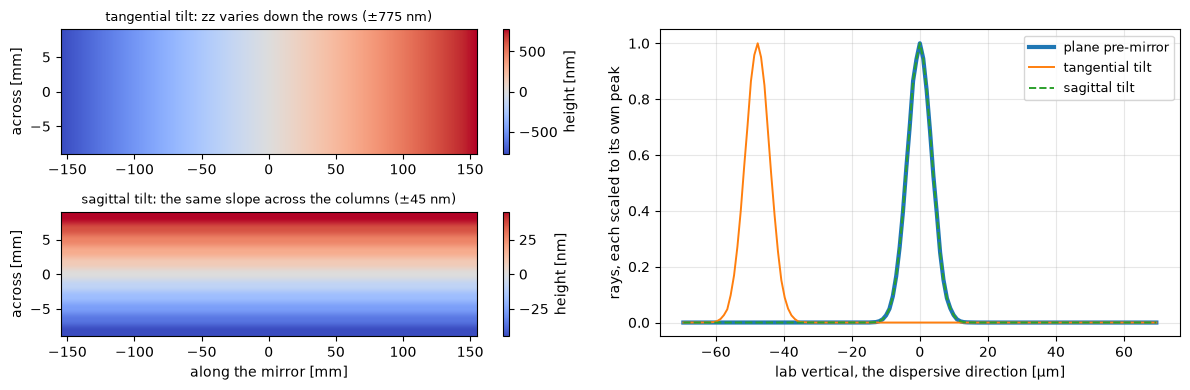

tilt 5 µrad along the mirror: image moves -47.67 µm, expected 47.66 µm towards -column 1
lever arm 4.767 m traced against 4.766 m from r'/c - M·L_MG
the same tilt across the mirror: image moves +0.0000 µm


In [15]:
tilt_rad = 5e-6
xx_m = np.linspace(-0.009, 0.009, 11)     # across the mirror: 11 columns cover its ±8 mm
yy_m = np.linspace(-0.155, 0.155, 621)    # along it: 0.5 mm steps, exactly the aperture

zz_tilt_m = np.outer(tilt_rad * yy_m, np.ones_like(xx_m))    # tangential tilt: rows vary
zz_across_m = np.outer(np.ones_like(yy_m), tilt_rad * xx_m)  # the same slope, columns vary

beam_tilt, _ = trace(premirror_with_map(xx_m, yy_m, zz_tilt_m))
beam_across, _ = trace(premirror_with_map(xx_m, yy_m, zz_across_m))

c_factor = np.cos(beta_rad) / np.cos(alpha_rad)                    # Part 2, 3.2
magnification = r_prime_m / (r_m * c_factor)
lever_m = r_prime_m / c_factor - magnification * (2 * 0.0886895)   # L_MG, the mirror-grating gap

fig = plt.figure(figsize=(12, 4))
maps = [(fig.add_subplot(2, 2, 1), zz_tilt_m, "tangential tilt: zz varies down the rows"),
        (fig.add_subplot(2, 2, 3), zz_across_m, "sagittal tilt: the same slope across the columns")]
for ax, zz_m, title in maps:
    # Each map on its own colour scale: the mirror is 17 times longer than it is wide, so the
    # same slope is a much smaller height across it.
    im = ax.imshow(zz_m.T * 1e9, origin="lower", aspect="auto", cmap="coolwarm",
                   vmin=-np.abs(zz_m).max() * 1e9, vmax=np.abs(zz_m).max() * 1e9,
                   extent=[yy_m[0] * 1e3, yy_m[-1] * 1e3, xx_m[0] * 1e3, xx_m[-1] * 1e3])
    ax.set_title(f"{title} (±{np.abs(zz_m).max() * 1e9:.0f} nm)", fontsize=9)
    ax.set_ylabel("across [mm]")
    fig.colorbar(im, ax=ax, label="height [nm]")
maps[1][0].set_xlabel("along the mirror [mm]")

ax = fig.add_subplot(1, 2, 2)
for b, name, style, width in ((beam_ideal, "plane pre-mirror", "-", 3.0),
                              (beam_tilt, "tangential tilt", "-", 1.4),
                              (beam_across, "sagittal tilt", "--", 1.4)):
    _, v_m = lab_frame(b)
    counts, edges = np.histogram(v_m * 1e6, bins=141, range=(-70, 70))
    ax.plot((edges[:-1] + edges[1:]) / 2, counts / counts.max(), style, lw=width, label=name)
ax.set_xlabel("lab vertical, the dispersive direction [µm]")
ax.set_ylabel("rays, each scaled to its own peak")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

shift_m = centroid(beam_tilt, 1) - centroid(beam_ideal, 1)

# How far the image moves is the formula above. *Which way* is fixed by the three azimuths
# rather than by any of this, so measure it here, once, and reuse it in 4.2 and 4.4.
sense = np.sign(shift_m / tilt_rad)

print(f"tilt {tilt_rad * 1e6:.0f} µrad along the mirror: image moves {shift_m * 1e6:+.2f} µm, "
      f"expected {2 * tilt_rad * lever_m * 1e6:.2f} µm "
      f"towards {'-' if sense < 0 else '+'}column 1")
print(f"lever arm {abs(shift_m) / (2 * tilt_rad):.3f} m traced against {lever_m:.3f} m from r'/c - M·L_MG")
print(f"the same tilt across the mirror: image moves "
      f"{(centroid(beam_across, 1) - centroid(beam_ideal, 1)) * 1e6:+.4f} µm")

assert np.isclose(abs(shift_m), 2 * tilt_rad * lever_m, rtol=0.002)         # the image moves by 2θ·L_eff
assert abs(centroid(beam_across, 1) - centroid(beam_ideal, 1)) < 0.01e-6    # and a sagittal tilt does not
assert np.isclose(rms(beam_tilt, 1), rms(beam_ideal, 1), rtol=0.01)         # a tilt moves the image, not its size

### 4.2 Your own error

A tilt only moves the image; to make it *worse*, the surface has to bend. The cheapest bend to write down is a ripple:

$$z(y) = A \sin\!\left(\frac{2\pi y}{\Lambda}\right), \qquad \sigma_\text{slope} = \frac{2\pi A}{\sqrt{2}\,\Lambda}.$$

Note which way round that works. The rays feel the slope, so the amplitude that matters depends on the period: 11 nm over a 50 mm period is 1 µrad rms, while the same 11 nm spread over the whole mirror would be thirty times gentler. One µrad rms is a deliberately terrible mirror — with a 4.8 m lever arm it should add some 9 µm of blur to an image 3.6 µm wide.

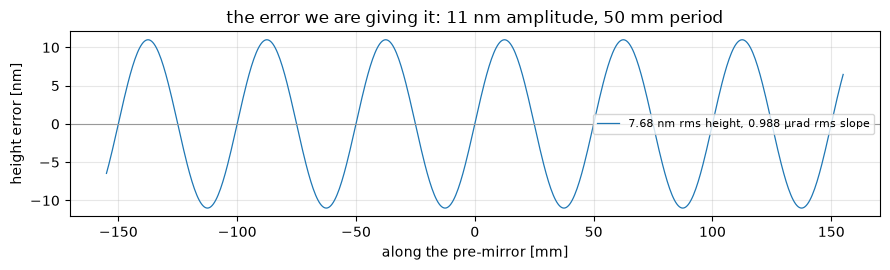

In [16]:
period_m, amplitude_m = 0.050, 11e-9
ripple_m = amplitude_m * np.sin(2 * np.pi * yy_m / period_m)
zz_ripple_m = np.outer(ripple_m, np.ones_like(xx_m))          # one profile, tiled across the width
sigma_slope_rad = np.gradient(ripple_m, yy_m).std()

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(yy_m * 1e3, ripple_m * 1e9, lw=0.9,
        label=f"{ripple_m.std() * 1e9:.2f} nm rms height, {sigma_slope_rad * 1e6:.3f} µrad rms slope")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("along the pre-mirror [mm]")
ax.set_ylabel("height error [nm]")
ax.set_title(f"the error we are giving it: {amplitude_m * 1e9:.0f} nm amplitude, "
             f"{period_m * 1e3:.0f} mm period")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

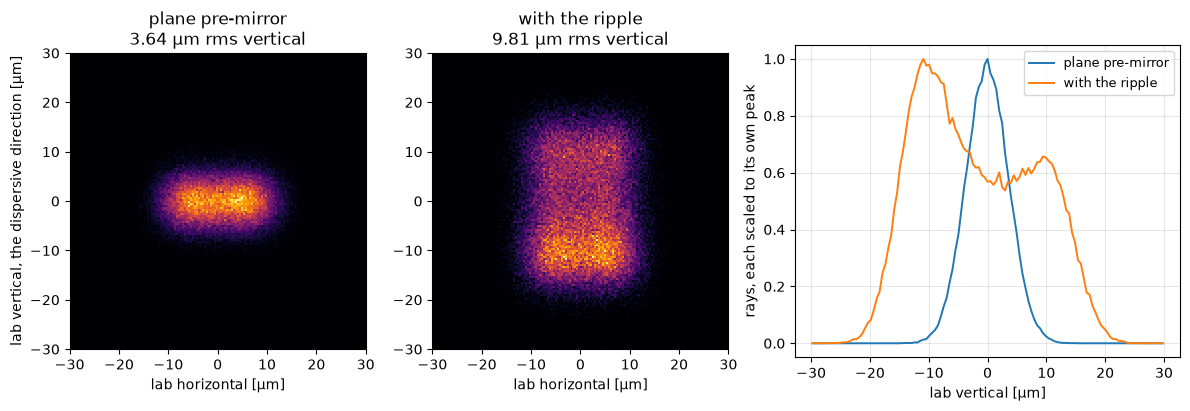

dispersive rms 3.64 µm -> 9.81 µm   (blur 9.42 µm in quadrature: 10.10 µm)
centroid -1.85 µm against -1.85 µm from the mean slope under the footprint (+194 nrad)


In [17]:
beam_ripple, footprint_ripple = trace(premirror_with_map(xx_m, yy_m, zz_ripple_m))

window_um = 30   # the same window on both images: autoscaled axes make any two look alike
fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1, 1.3]})
for ax, b, name in ((axes[0], beam_ideal, "plane pre-mirror"), (axes[1], beam_ripple, "with the ripple")):
    h_m, v_m = lab_frame(b)
    ax.hist2d(h_m * 1e6, v_m * 1e6, bins=[150, 150],
              range=[[-window_um, window_um], [-window_um, window_um]], cmap="inferno")
    ax.set_title(f"{name}\n{v_m.std() * 1e6:.2f} µm rms vertical")
    ax.set_xlabel("lab horizontal [µm]")
    ax.set_aspect("equal")
    counts, edges = np.histogram(v_m * 1e6, bins=121, range=(-window_um, window_um))
    axes[2].plot((edges[:-1] + edges[1:]) / 2, counts / counts.max(), lw=1.4, label=name)
axes[0].set_ylabel("lab vertical, the dispersive direction [µm]")
axes[2].set_xlabel("lab vertical [µm]")
axes[2].set_ylabel("rays, each scaled to its own peak")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Hand estimate: the blur is 2 σ_slope × the lever arm, in quadrature with the ideal image.
blur_m = 2 * sigma_slope_rad * lever_m
print(f"dispersive rms {rms(beam_ideal, 1) * 1e6:.2f} µm -> {rms(beam_ripple, 1) * 1e6:.2f} µm   "
      f"(blur {blur_m * 1e6:.2f} µm in quadrature: {np.hypot(rms(beam_ideal, 1), blur_m) * 1e6:.2f} µm)")

# The centroid moves too, by the mean slope over the patch of mirror the beam actually
# covers — which is the whole mirror's mean only if the beam fills it. Section 4.4 lives here.
y_hit_m = footprint_ripple.rays[footprint_ripple.rays[:, 9] > 0, 1]
slope_hit_rad = (2 * np.pi * amplitude_m / period_m) * np.cos(2 * np.pi * y_hit_m / period_m)
print(f"centroid {(centroid(beam_ripple, 1) - centroid(beam_ideal, 1)) * 1e6:+.2f} µm against "
      f"{sense * 2 * slope_hit_rad.mean() * lever_m * 1e6:+.2f} µm from the mean slope under the "
      f"footprint ({slope_hit_rad.mean() * 1e9:+.0f} nrad)")

assert np.isclose(rms(beam_ripple, 1), np.hypot(rms(beam_ideal, 1), blur_m), rtol=0.05)
assert np.isclose(centroid(beam_ripple, 1) - centroid(beam_ideal, 1),
                  sense * 2 * slope_hit_rad.mean() * lever_m, rtol=0.05)
assert np.isclose(rms(beam_ripple, 3), rms(beam_ideal, 3), rtol=0.01)   # the horizontal is untouched

Nearly three times wider, and no longer a Gaussian: a horn on each side. That is the signature of a single-frequency slope error — a sinusoid spends most of its length near its extreme slopes. Many frequencies together would give a Gaussian blur instead.

### 4.3 What it does to two nearby energies

A width is not yet an answer. What the monochromator is for is separating photon energies, so ask it directly, with Part 2's probe: three lines from the source, $E$ and $E(1 \pm \delta)$ at $\delta$ = 1/5000, and column 26 — each ray's own photon energy — to tell them apart again at the screen.

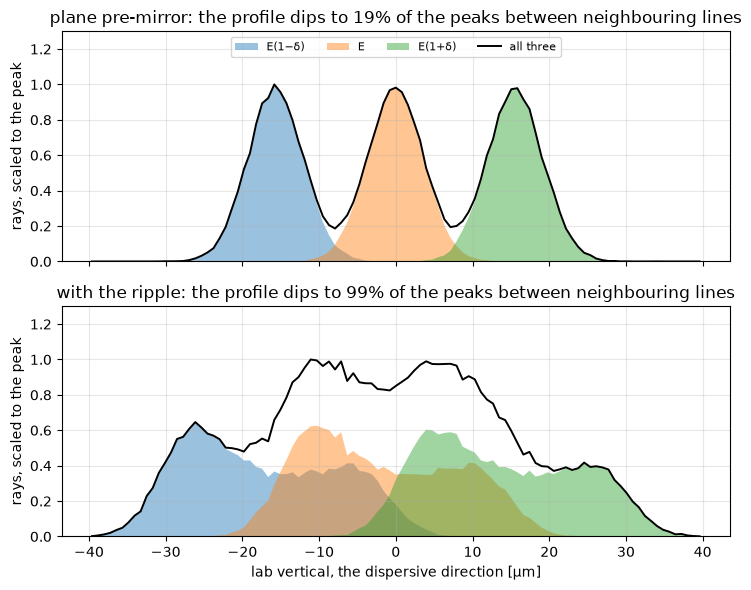

line spacing 15.63 µm ideal, 15.67 µm rippled;  each line 3.64 µm -> 9.81 µm rms wide


In [18]:
probe = 1 / 5000
beam_ideal_3, _ = trace(energy_spread=probe)
beam_ripple_3, _ = trace(premirror_with_map(xx_m, yy_m, zz_ripple_m), energy_spread=probe)

edges_um = np.linspace(-40, 40, 102)
centres_um = (edges_um[:-1] + edges_um[1:]) / 2


def line_positions_um(b, energy_eV=1000.0):
    # Where each of the three lines lands: its own centroid, picked out by column 26 —
    # each ray's photon energy, which survives the whole beamline.
    line_eV = b.get_column(26, nolost=1)
    _, v_m = lab_frame(b)
    return np.array([v_m[np.abs(line_eV - energy_eV * (1 + k * probe)) < energy_eV * probe / 2].mean()
                     for k in (-1, 0, 1)]) * 1e6


def dips(profile, positions_um):
    # Two lines are resolved when the profile dips between them. Measure each dip as a
    # fraction of the smaller peak it sits between: near 0 is two clean lines, 1 is one lump.
    out = []
    for lower_um, upper_um in zip(positions_um[:-1], positions_um[1:]):
        between = (centres_um >= lower_um) & (centres_um <= upper_um)
        ends = min(np.interp(lower_um, centres_um, profile), np.interp(upper_um, centres_um, profile))
        out.append(profile[between].min() / ends)
    return np.array(out)


measured = {}
fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
for ax, b, name in ((axes[0], beam_ideal_3, "plane pre-mirror"),
                    (axes[1], beam_ripple_3, "with the ripple")):
    line_eV = b.get_column(26, nolost=1)
    _, v_m = lab_frame(b)
    total = np.histogram(v_m * 1e6, bins=edges_um)[0].astype(float)
    for offset, label in ((-1, "E(1−δ)"), (0, "E"), (+1, "E(1+δ)")):
        on_this_line = np.abs(line_eV - 1000.0 * (1 + offset * probe)) < 1000.0 * probe / 2
        ax.fill_between(centres_um, np.histogram(v_m[on_this_line] * 1e6, bins=edges_um)[0] / total.max(),
                        alpha=0.45, label=label)
    ax.plot(centres_um, total / total.max(), "k", lw=1.4, label="all three")

    positions_um = line_positions_um(b)
    measured[name] = (positions_um, dips(total, positions_um))
    ax.set_title(f"{name}: the profile dips to {measured[name][1].mean() * 100:.0f}% "
                 f"of the peaks between neighbouring lines")
    ax.set_ylabel("rays, scaled to the peak")
    ax.set_ylim(0, 1.3)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=4, loc="upper center")
axes[1].set_xlabel("lab vertical, the dispersive direction [µm]")
plt.tight_layout()
plt.show()

spacing_ideal_um = np.diff(measured["plane pre-mirror"][0]).mean()
spacing_ripple_um = np.diff(measured["with the ripple"][0]).mean()
print(f"line spacing {abs(spacing_ideal_um):.2f} µm ideal, {abs(spacing_ripple_um):.2f} µm rippled;"
      f"  each line {rms(beam_ideal, 1) * 1e6:.2f} µm -> {rms(beam_ripple, 1) * 1e6:.2f} µm rms wide")

assert np.all(measured["plane pre-mirror"][1] < 0.5)   # resolved: a clear valley between lines
assert np.all(measured["with the ripple"][1] > 0.9)    # not resolved: no valley left
assert np.isclose(spacing_ideal_um, spacing_ripple_um, rtol=0.02)   # the grating disperses just the same
assert abs(spacing_ideal_um) > 2.3548 * rms(beam_ideal, 1) * 1e6    # ideal: further apart than they are wide
assert abs(spacing_ripple_um) < 2.3548 * rms(beam_ripple, 1) * 1e6  # rippled: not

The lines land in the same three places either way — the ripple does not touch the grating's dispersion. What it changes is the width of each one, and three lines three times wider run together: the valley between neighbours fills in from about a fifth of the peak to all of it, and this beamline can no longer tell 1000 eV from 1000.2 eV.

### 4.4 The real thing

The ripple was ours to choose. This is COSMIC-U's actual pre-mirror, measured at the metrology lab: a text file with a short instrument header and two columns, position in mm and height in nm.

Nothing converts it for us — we read the two columns, tile the profile across the width, and hand `shadow4` the arrays, exactly as in 4.1 and 4.2.

In [19]:
rows = []
for line in open("data/COSMIC-U_M2_IntegratedHeight.dat"):
    parts = line.split()
    if len(parts) == 2:
        try:
            rows.append([float(p) for p in parts])   # a data line is two numbers; a header line is not
        except ValueError:
            pass
raw = np.array(rows)
position_m, measured_m = raw[:, 0] * 1e-3, raw[:, 1] * 1e-9     # mm and nm in the file, metres here

# The header says what to expect: 1551 points, 0.2 mm apart, over a 310 mm mirror.
assert len(raw) == 1551
assert np.isclose(np.diff(position_m).mean(), 0.2e-3, rtol=1e-6)
assert np.isclose(np.ptp(position_m), 0.310, atol=1e-6)

# And it has to cover the aperture, as in 3.2 — here it is the aperture, to the micron.
x_left, x_right, y_bottom, y_top = mirror.get_boundary_shape().get_boundaries()
assert position_m.min() <= y_bottom + 1e-6 and position_m.max() >= y_top - 1e-6
print(f"{len(raw)} points, {np.diff(position_m).mean() * 1e3:.1f} mm apart, "
      f"{position_m.min() * 1e3:+.1f} to {position_m.max() * 1e3:+.1f} mm — the pre-mirror's full length")

1551 points, 0.2 mm apart, -155.0 to +155.0 mm — the pre-mirror's full length


**What the mirror is doing.** Most of a polished mirror's height error is usually one gentle bend, and a bend is not a defect you can polish out — it is a radius. Fitting a parabola and subtracting it separates the two: the fit is the radius of curvature, and what is left is the figure error proper.

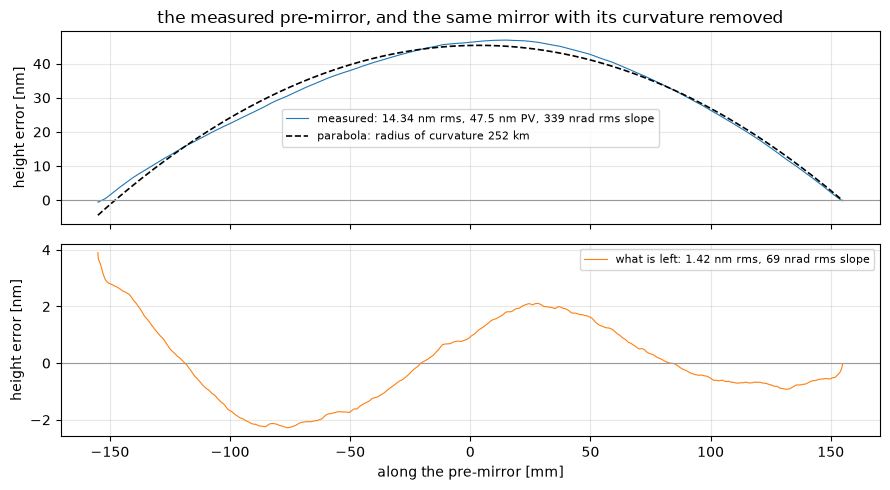

In [20]:
coefficients = np.polyfit(position_m, measured_m, 2)             # height [m] against position [m]
trend_m = np.polyval(coefficients, position_m)
residual_m = measured_m - trend_m
radius_m = abs(1 / (2 * coefficients[0]))                        # a parabola z = y²/2R

slope_rad = np.gradient(measured_m, position_m)
residual_slope_rad = np.gradient(residual_m, position_m)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(position_m * 1e3, measured_m * 1e9, lw=0.8,
             label=f"measured: {measured_m.std() * 1e9:.2f} nm rms, {np.ptp(measured_m) * 1e9:.1f} nm PV, "
                   f"{slope_rad.std() * 1e9:.0f} nrad rms slope")
axes[0].plot(position_m * 1e3, trend_m * 1e9, "k--", lw=1.2,
             label=f"parabola: radius of curvature {radius_m / 1e3:.0f} km")
axes[1].plot(position_m * 1e3, residual_m * 1e9, lw=0.8, color="tab:orange",
             label=f"what is left: {residual_m.std() * 1e9:.2f} nm rms, "
                   f"{residual_slope_rad.std() * 1e9:.0f} nrad rms slope")
for ax in axes:
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_ylabel("height error [nm]")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[1].set_xlabel("along the pre-mirror [mm]")
axes[0].set_title("the measured pre-mirror, and the same mirror with its curvature removed")
plt.tight_layout()
plt.show()

# A parabola of radius R sags by L²/8R over a length L: that sag should be the map's whole
# peak-to-valley, which is another way of saying this mirror is a radius plus very little.
assert np.isclose(np.ptp(position_m) ** 2 / (8 * radius_m), np.ptp(measured_m), rtol=0.05)
assert residual_m.std() < 0.15 * measured_m.std()

**So what does it cost?** The ripple of 4.2 was 1 µrad rms and tripled the image. This mirror is 339 nrad rms over its full length — a real optic, and a third of the ripple. Trace it at 1000 eV, then across the grating's whole range, and see.

The scan needs Part 2's two functions, which turn a photon energy into the source size and the optics' angles and distances. They are copied in unchanged.

In [21]:
from scipy.optimize import brentq


def pgm_solve(energy_eV, g0_per_m=g0_per_m, g1_per_m2=g1_per_m2,
              r_m=r_m, r_prime_m=r_prime_m, dy_m=dy_m):
    # Part 2, 3.2: the grating equation and the focus condition, solved at one photon energy.
    wavelength_m = hc_eVm / energy_eV
    path_r_m = r_m
    for _ in range(4):
        def focus_residual(a_rad):
            b_rad = np.arcsin(np.sin(a_rad) - wavelength_m * g0_per_m)
            return np.cos(a_rad)**2 / path_r_m + np.cos(b_rad)**2 / r_prime_m - wavelength_m * g1_per_m2
        alpha_rad = brentq(focus_residual, 0.0, np.radians(89.999), xtol=1e-15)
        beta_rad = np.arcsin(np.sin(alpha_rad) - wavelength_m * g0_per_m)
        D_rad = np.pi - alpha_rad - beta_rad
        L_MG_m = dy_m / np.sin(D_rad)
        d_SM_m = r_m - dy_m / np.tan(D_rad)
        path_r_m = d_SM_m + L_MG_m
    return {"alpha_rad": alpha_rad, "beta_rad": beta_rad, "mirror_rad": (alpha_rad + beta_rad) / 2,
            "d_SM_m": d_SM_m, "L_MG_m": L_MG_m, "cff": np.cos(beta_rad) / np.cos(alpha_rad)}


def source_sizes(energy_eV):
    # Part 2, 4.2: electron beam ⊕ undulator emission, in quadrature.
    wavelength_m = hc_eVm / energy_eV
    emittance_m, beta_x_m, beta_y_m, undulator_m = 71e-12, 2.05, 3.0, 2.0
    photon_size_m = np.sqrt(2 * wavelength_m * undulator_m) / (2 * np.pi)
    photon_div_rad = np.sqrt(wavelength_m / (2 * undulator_m))
    return {"sigma_h_m": np.hypot(np.sqrt(emittance_m * beta_x_m), photon_size_m),
            "sigma_v_m": np.hypot(np.sqrt(emittance_m * beta_y_m), photon_size_m),
            "div_h_rad": np.hypot(np.sqrt(emittance_m / beta_x_m), photon_div_rad),
            "div_v_rad": np.hypot(np.sqrt(emittance_m / beta_y_m), photon_div_rad)}

In [22]:
premirror_measured = premirror_with_map(xx_m, position_m, np.outer(measured_m, np.ones_like(xx_m)))
beam_measured, footprint_measured = trace(premirror_measured)

print(f"dispersive rms {rms(beam_ideal, 1) * 1e6:.3f} µm -> {rms(beam_measured, 1) * 1e6:.3f} µm   "
      f"({(rms(beam_measured, 1) / rms(beam_ideal, 1) - 1) * 100:.1f}%), centroid "
      f"{(centroid(beam_measured, 1) - centroid(beam_ideal, 1)) * 1e6:+.2f} µm")

# The same two hand estimates as 4.2, from the slope the rays actually land on. The beam
# covers -64…+64 mm of this 310 mm mirror, and over that patch the mirror is far better
# than its full-length number: a mean tilt moves the image, the spread about it blurs.
y_hit_m = footprint_measured.rays[footprint_measured.rays[:, 9] > 0, 1]
slope_hit_rad = np.interp(y_hit_m, position_m, slope_rad)
print(f"footprint {y_hit_m.min() * 1e3:+.1f} to {y_hit_m.max() * 1e3:+.1f} mm, where the slope error is "
      f"{slope_hit_rad.mean() * 1e9:+.0f} nrad mean and {slope_hit_rad.std() * 1e9:.0f} nrad rms about it "
      f"— not the {slope_rad.std() * 1e9:.0f} nrad of the whole mirror")

assert np.isclose(rms(beam_measured, 1),
                  np.hypot(rms(beam_ideal, 1), 2 * slope_hit_rad.std() * lever_m), rtol=0.02)
assert np.isclose(centroid(beam_measured, 1) - centroid(beam_ideal, 1),
                  sense * 2 * slope_hit_rad.mean() * lever_m, rtol=0.05)

dispersive rms 3.641 µm -> 3.691 µm   (1.4%), centroid -0.55 µm
footprint -63.8 to +64.2 mm, where the slope error is +59 nrad mean and 80 nrad rms about it — not the 339 nrad of the whole mirror


63 traces in 37 s


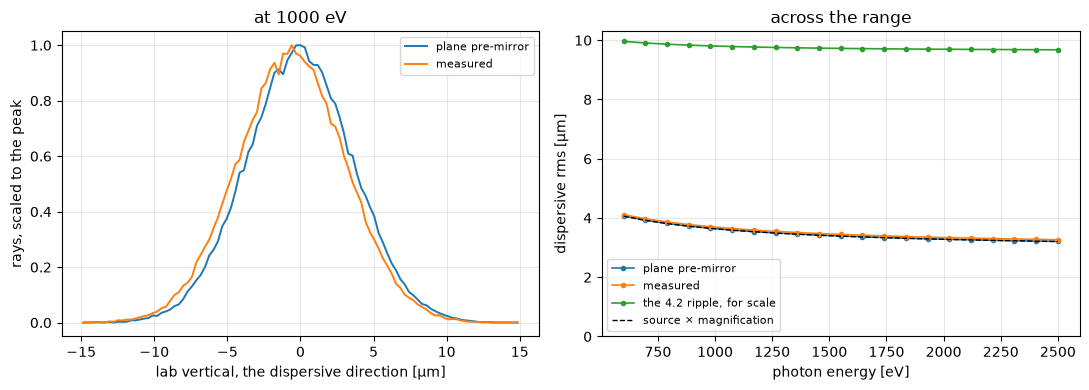

measured against plane: 1.1–1.8% across the range


In [23]:
# This one takes a while: 63 traces of 100 000 rays.
import time

scan_eV = np.linspace(600, 2500, 21)
configurations = {"plane pre-mirror": None, "measured": premirror_measured,
                  "the 4.2 ripple, for scale": premirror_with_map(xx_m, yy_m, zz_ripple_m)}

t0_s = time.time()
widths_m = {}
for name, premirror in configurations.items():
    widths_m[name] = np.array([rms(trace(premirror, energy_eV=energy_eV, source=source_sizes(energy_eV),
                                         geometry=pgm_solve(energy_eV))[0], 1)
                               for energy_eV in scan_eV])
print(f"{3 * len(scan_eV)} traces in {time.time() - t0_s:.0f} s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for b, name in ((beam_ideal, "plane pre-mirror"), (beam_measured, "measured")):
    _, v_m = lab_frame(b)
    counts, edges = np.histogram(v_m * 1e6, bins=101, range=(-15, 15))
    axes[0].plot((edges[:-1] + edges[1:]) / 2, counts / counts.max(), lw=1.4, label=name)
axes[0].set_xlabel("lab vertical, the dispersive direction [µm]")
axes[0].set_ylabel("rays, scaled to the peak")
axes[0].set_title("at 1000 eV")

for name, w_m in widths_m.items():
    axes[1].plot(scan_eV, w_m * 1e6, "o-", ms=3, lw=1.2, label=name)
# Part 2's hand estimate, unchanged: the vertical source, demagnified by the grating.
model_m = np.array([source_sizes(E)["sigma_v_m"] * r_prime_m / (r_m * pgm_solve(E)["cff"])
                    for E in scan_eV])
axes[1].plot(scan_eV, model_m * 1e6, "k--", lw=1, label="source × magnification")
axes[1].set_xlabel("photon energy [eV]")
axes[1].set_ylabel("dispersive rms [µm]")
axes[1].set_ylim(0, None)
axes[1].set_title("across the range")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"measured against plane: {(widths_m['measured'] / widths_m['plane pre-mirror'] - 1).min() * 100:.1f}"
      f"–{(widths_m['measured'] / widths_m['plane pre-mirror'] - 1).max() * 100:.1f}% across the range")

assert np.allclose(widths_m["plane pre-mirror"], model_m, rtol=0.015)          # Part 2's beamline, unchanged
assert np.all(widths_m["measured"] < 1.03 * widths_m["plane pre-mirror"])      # the real mirror costs ~1%
assert np.all(widths_m["the 4.2 ripple, for scale"] > 2 * widths_m["plane pre-mirror"])

A real mirror, three times worse than its specification, and the beam barely notices: about 1% wider at every energy, against the ripple's factor of three. The reason is in the printout above — the beam lands on 128 mm of a 310 mm mirror, and over that patch the slope error is 80 nrad, not 339. **A mirror's number is not what your beam feels; the footprint decides.**

One honest caveat. This is geometrical ray tracing: a ray feels the local slope and nothing else, so none of it knows about diffraction, coherence, or the scattering that fine-scale error produces. For a coherent beamline — and COSMIC-U is one — the same measured surface has to go through a wave code, where it enters as a phase error instead. The 1% here is a lower bound, not the whole answer.

## Wrap-up

Three notebooks, one habit: take the script Oasys writes, find the handful of numbers that are really arguments, and make it a function. Part 1 made the observation plane an argument, Part 2 the photon energy, and Part 3 the surface itself — first one we invented, then one that was measured.

Nothing here is specific to this beamline. `S4NumericalMeshMirror` takes arrays from anywhere, so the map can come from your own metrology file, a thermal model, or an error you are proposing to tolerate; the rest is your beamline's numbers instead of these.

## Appendix — Correcting the Error

The refocusing mirror of Section 3 is an **adaptive optic**: 18 piezo actuators are bonded to the back of the substrate, each bending the surface by a known shape per volt. Its *influence functions* were measured once and published ([Zenodo 15107331](https://zenodo.org/records/15107331), `infFn.mat`); `tutorial/data/` carries a copy.

That turns correction into a least-squares problem — find the combination of actuator shapes closest to the measured error, and apply its negative. What gets traced is the **residual**, which replaces the map on the mirror rather than adding a second one.

In [24]:
from scipy.io import loadmat

influence = loadmat("data/infFn.mat")
influence_w, influence_position_m = influence["infFn_w"], influence["y_m"]   # wave/V, and where

# The file is NaN-padded outside the illuminated strip; keep the finite block.
finite = np.isfinite(influence_w)
rows, columns = np.flatnonzero(finite.any(axis=1)), np.flatnonzero(finite.any(axis=0))
actuators_w = influence_w[rows[0]:rows[-1] + 1, columns[0]:columns[-1] + 1]
actuator_position_m = influence_position_m[rows[0]:rows[-1] + 1].ravel()
assert not np.isnan(actuators_w).any()

# Two extra shapes on top of the actuators: piston and a linear tilt, scaled to the
# first actuator's peak so they weigh the same in the fit. They are not actuators —
# they absorb the offset and slope that realigning the mirror would take out, so the
# actuators are not spent on them.
n_actuators = actuators_w.shape[1]
peak_w = actuators_w[:, 0].max()
basis_w = np.column_stack([actuators_w,
                           np.full(actuators_w.shape[0], peak_w),
                           actuator_position_m / actuator_position_m.max() * peak_w])

# The file's coordinate is a beam-plane one, ±0.35 mm, not a position on the mirror —
# so this stretch assumes the actuator array spans exactly the measured length. Fine
# for seeing what the correction does; not a number to set a machine by.
basis_on_mirror_w = np.column_stack([np.interp(np.linspace(actuator_position_m.min(),
                                                           actuator_position_m.max(), map_y_m.size),
                                               actuator_position_m, basis_w[:, j])
                                     for j in range(basis_w.shape[1])])
print(f"{n_actuators} actuators + piston + tilt = {basis_w.shape[1]} degrees of freedom, "
      f"stretched onto the map's {map_y_m.size} points")

18 actuators + piston + tilt = 20 degrees of freedom, stretched onto the map's 1260 points


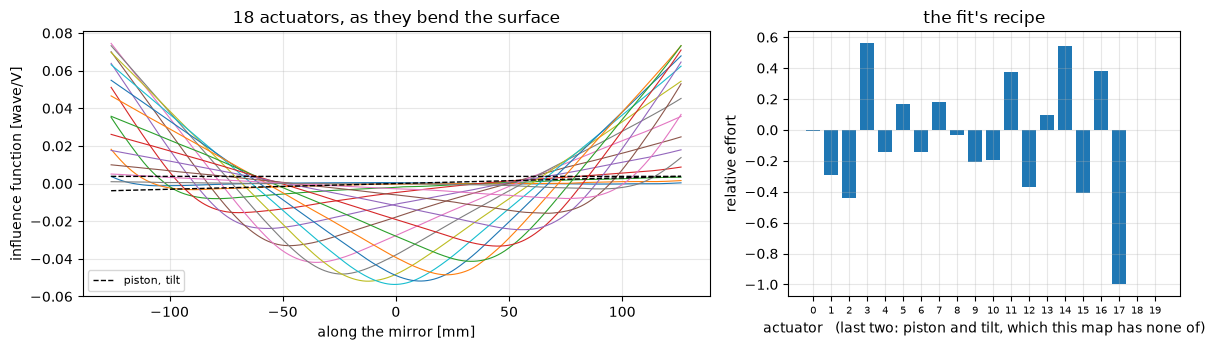

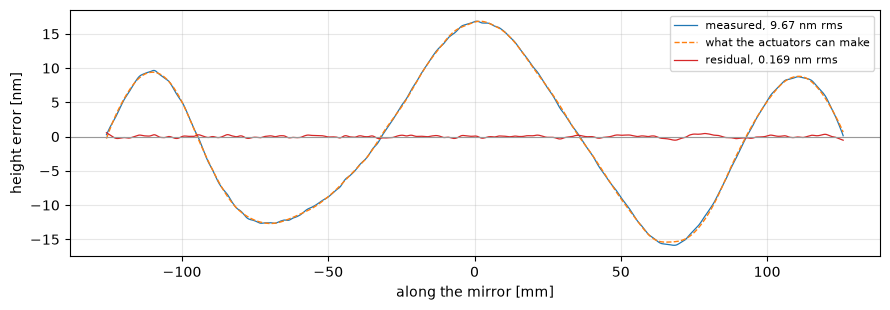

In [25]:
# Least squares: which combination of those shapes is closest to the measured map?
coefficients, _, rank, _ = np.linalg.lstsq(basis_on_mirror_w, map_z_m, rcond=None)
fit_m = basis_on_mirror_w @ coefficients
residual_m = map_z_m - fit_m

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
axes[0].plot(map_y_m * 1e3, basis_on_mirror_w[:, :n_actuators], lw=0.8)
axes[0].plot(map_y_m * 1e3, basis_on_mirror_w[:, n_actuators], "k--", lw=1.0, label="piston, tilt")
axes[0].plot(map_y_m * 1e3, basis_on_mirror_w[:, n_actuators + 1], "k--", lw=1.0)
axes[0].set_xlabel("along the mirror [mm]")
axes[0].set_ylabel("influence function [wave/V]")
axes[0].set_title(f"{n_actuators} actuators, as they bend the surface")
axes[0].legend(fontsize=8)
axes[1].bar(np.arange(coefficients.shape[0]), coefficients[:, 0] / abs(coefficients[:, 0]).max(),
            color=["C0"] * n_actuators + ["C3", "C3"])
axes[1].set_xticks(np.arange(coefficients.shape[0]))
axes[1].tick_params(axis="x", labelsize=7)
axes[1].set_xlabel("actuator   (last two: piston and tilt, which this map has none of)")
axes[1].set_ylabel("relative effort")
axes[1].set_title("the fit's recipe")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(map_y_m * 1e3, map_z_m[:, 0] * 1e9, lw=0.9, label=f"measured, {map_z_m.std() * 1e9:.2f} nm rms")
ax.plot(map_y_m * 1e3, fit_m[:, 0] * 1e9, "--", lw=1.0, label="what the actuators can make")
ax.plot(map_y_m * 1e3, residual_m[:, 0] * 1e9, lw=0.9, color="C3",
        label=f"residual, {residual_m.std() * 1e9:.3f} nm rms")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("along the mirror [mm]")
ax.set_ylabel("height error [nm]")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# The map is one profile tiled across the width, so every sagittal column has to solve
# to the same recipe — a transposed mesh (4.1) would fail here instantly.
assert np.allclose(coefficients, coefficients[:, [0]])
assert rank == basis_on_mirror_w.shape[1]
assert residual_m.std() < 0.05 * map_z_m.std()

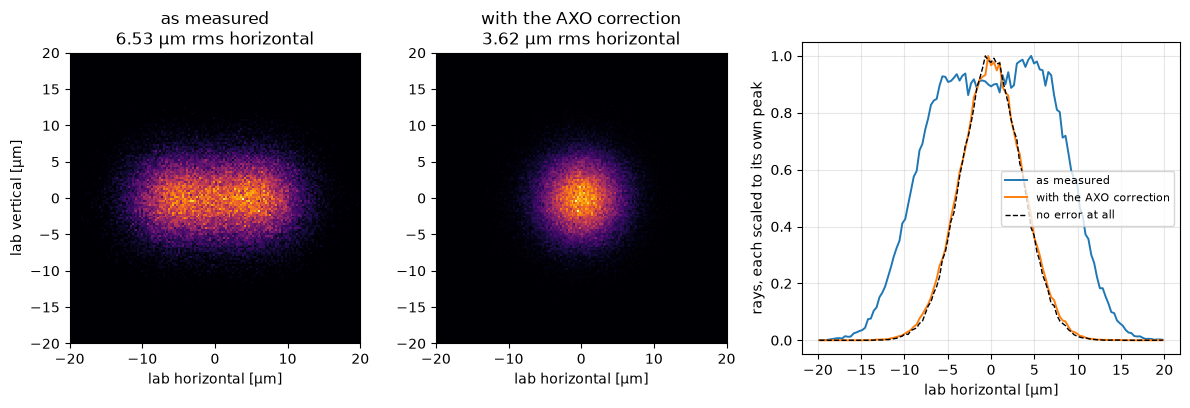

lab horizontal rms 6.53 µm measured -> 3.62 µm corrected, against 3.49 µm with no error at all: 96% of the excess removed
dispersive rms 3.641 -> 3.641 µm


In [26]:
def ellipse_with_map(zz_m):
    # Section 3.2's three objects once more: the ideal ellipse, a mesh, and their sum.
    mesh = S4NumericalMeshMirror(name='refocusing mirror surface', boundary_shape=None,
        xx=map_x_m, yy=map_y_m, zz=zz_m, surface_data_file=None,
        f_reflec=0, f_refl=0, file_refl='', refraction_index=1,
        coating_material='', coating_density=1, coating_roughness=0, dabax=None,
        )
    return S4AdditionalNumericalMeshMirror(name='Elliptical Mirror H',
                                           ideal_mirror=ideal_mirror, numerical_mesh_mirror=mesh)


# The residual replaces the map — it is not a second mesh in front of it.
beam_corrected, _ = trace(ellipse=ellipse_with_map(residual_m))
beam_no_error, _ = trace(ellipse=ellipse_with_map(np.zeros_like(map_z_m)))   # for reference

window_um = 20
fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1, 1.3]})
for ax, b, name in ((axes[0], beam_ideal, "as measured"), (axes[1], beam_corrected, "with the AXO correction")):
    h_m, v_m = lab_frame(b)
    ax.hist2d(h_m * 1e6, v_m * 1e6, bins=[150, 150],
              range=[[-window_um, window_um], [-window_um, window_um]], cmap="inferno")
    ax.set_title(f"{name}\n{h_m.std() * 1e6:.2f} µm rms horizontal")
    ax.set_xlabel("lab horizontal [µm]")
    ax.set_aspect("equal")
    counts, edges = np.histogram(h_m * 1e6, bins=121, range=(-window_um, window_um))
    axes[2].plot((edges[:-1] + edges[1:]) / 2, counts / counts.max(), lw=1.4, label=name)
axes[0].set_ylabel("lab vertical [µm]")
h_m, _ = lab_frame(beam_no_error)
counts, edges = np.histogram(h_m * 1e6, bins=121, range=(-window_um, window_um))
axes[2].plot((edges[:-1] + edges[1:]) / 2, counts / counts.max(), "k--", lw=1.0, label="no error at all")
axes[2].set_xlabel("lab horizontal [µm]")
axes[2].set_ylabel("rays, each scaled to its own peak")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

excess_before_m = rms(beam_ideal, 3) - rms(beam_no_error, 3)
excess_after_m = rms(beam_corrected, 3) - rms(beam_no_error, 3)
print(f"lab horizontal rms {rms(beam_ideal, 3) * 1e6:.2f} µm measured -> "
      f"{rms(beam_corrected, 3) * 1e6:.2f} µm corrected, against {rms(beam_no_error, 3) * 1e6:.2f} µm "
      f"with no error at all: {(1 - excess_after_m / excess_before_m) * 100:.0f}% of the excess removed")
print(f"dispersive rms {rms(beam_ideal, 1) * 1e6:.3f} -> {rms(beam_corrected, 1) * 1e6:.3f} µm")

assert excess_after_m < 0.15 * excess_before_m                          # most of the penalty is gone
assert np.isclose(rms(beam_corrected, 1), rms(beam_ideal, 1), rtol=0.005)   # and the dispersive direction never moved

Nineteen twentieths of the penalty, from a fit and one more trace. Worth being clear about what this is and is not: the actuators' shapes are measured, but the fit assumes they span the mirror exactly as the file's coordinate suggests, and a real correction is set by measuring the mirror *in situ* and iterating. What the model gives you is the answer to the question worth asking first — how much of this particular error is even correctable.